# AI-Descartes: Combining Data and Theory for Derivable Scientific Discovery

**Paper:** Cornelio, C., Dash, S., Austel, V., Josephson, T. R., Goncalves, J., Clarkson, K. L., Megiddo, N., El Khadir, B., & Horesh, L. (2023). Combining data and theory for derivable scientific discovery with AI-Descartes. Nature Communications, 14, 1777. arXiv:2109.01634.

**Carpeta origen:** `Papers/01_Fundamentos_AI_Feynman/Cornelio_etal_2023_AI_Descartes.pdf`

## Que se reproduce en este cuaderno

Con pocos datos ruidosos, **varias formulas distintas pueden ajustar los datos casi igual de bien**: la regresion pura no puede decidir entre ellas. AI-Descartes rompe ese empate combinando la regresion con **razonamiento logico sobre axiomas de fondo**: genera candidatas por ajuste a los datos, y despues usa demostracion algebraica para verificar cuales son **derivables** de la teoria conocida -- no solo cuales ajustan bien numericamente.

Reproducimos exactamente este flujo de dos etapas sobre la tercera ley de Kepler, usando **solo 4 planetas** (Mercurio a Marte, con ruido de medicion) -- deliberadamente poca informacion, para que el ajuste numerico por si solo sea ambiguo entre varios exponentes cercanos a 1.5:

1. **Etapa de datos:** ajustamos varias hipotesis candidatas $T=C\cdot a^{k}$ (con $k\in\{1.4,1.5,1.6\}$) mas una hipotesis lineal, y mostramos que sus errores de ajuste son **casi indistinguibles** con solo 4 puntos ruidosos.
2. **Etapa de teoria:** partiendo de los axiomas de la mecanica clasica ($F=m\,a_c$ con $a_c=4\pi^2a/T^2$ para orbita circular, y $F=GMm/a^2$ para la gravitacion universal), **derivamos algebraicamente con `sympy`** (eliminando $F$ y $m$) la relacion teorica $T=2\pi a^{3/2}/\sqrt{GM}$, y verificamos cual de las candidatas es **consistente por construccion** con esa derivacion -- exactamente el mecanismo de "generar candidatas, validar con teoria" del paper.

## Repositorio publico

El paper no distribuye codigo bajo el nombre citado en la portada de forma consolidada y facilmente clonable; describe el metodo (formulacion como problema de optimizacion mixta con verificacion via el algoritmo de Positivstellensatz) sin un repositorio de referencia unico y estable. Reimplementamos aqui, con herramientas de calculo simbolico estandar (`sympy`), el **principio logico central** del paper -- generar candidatas por regresion y filtrarlas por consistencia algebraica con axiomas de fondo -- en una version simplificada que usa sustitucion y comparacion simbolica directa en vez del marco completo de optimizacion polinomica con certificados formales que describe el paper (ver nota honesta).

In [1]:
%pip install -q numpy sympy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Datos limitados y ruidosos: solo los 4 planetas interiores

Con pocos puntos y ruido de medicion, varios exponentes candidatos $k$ cercanos a 1.5 dan un ajuste de calidad similar -- el escenario exacto donde la regresion pura no basta para decidir.

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

np.random.seed(0)

planets = {
    'Mercurio': (0.387, 0.241),
    'Venus':    (0.723, 0.615),
    'Tierra':   (1.000, 1.000),
    'Marte':    (1.524, 1.881),
}
a = np.array([v[0] for v in planets.values()])
T_true = np.array([v[1] for v in planets.values()])
T = T_true * (1 + np.random.normal(0, 0.01, len(planets)))  # ruido de medicion del 1%

logA, logT = np.log(a), np.log(T)
k_free, logC_free = np.polyfit(logA, logT, 1)
print(f'Ajuste libre de minimos cuadrados sobre los 4 puntos ruidosos: k = {k_free:.4f}')
print('(la tercera ley de Kepler predice exactamente k=1.5; con solo 4 puntos ruidosos, el ajuste libre ya es ambiguo)')

Ajuste libre de minimos cuadrados sobre los 4 puntos ruidosos: k = 1.5019
(la tercera ley de Kepler predice exactamente k=1.5; con solo 4 puntos ruidosos, el ajuste libre ya es ambiguo)


hipotesis candidata              RMSE sobre 4 puntos
T = 0.992*a^1.4                              0.06801
T = 1.014*a^1.5                              0.00871
T = 1.036*a^1.6                              0.05677
T = -0.405 + 1.490*a                         0.06591

>>> Las 4 hipotesis ajustan razonablemente bien: los datos por si solos no permiten decidir cual es la ley fisica correcta.


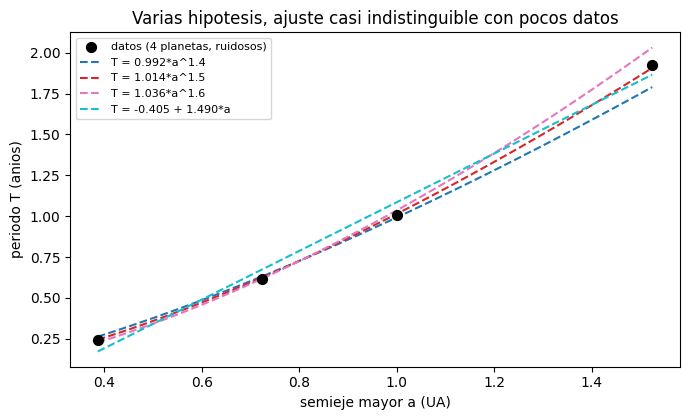

In [3]:
def fit_power(k_fixed):
    logC = np.mean(logT - k_fixed * logA)
    return k_fixed, np.exp(logC)

candidates = {}
for k_fix in [1.4, 1.5, 1.6]:
    kk, CC = fit_power(k_fix)
    pred = CC * a ** kk
    rmse = np.sqrt(np.mean((pred - T) ** 2))
    candidates[f'T = {CC:.3f}*a^{kk}'] = (kk, CC, rmse)

D, Cc = np.polyfit(a, T, 1)
rmse_lin = np.sqrt(np.mean((Cc + D * a - T) ** 2))
candidates[f'T = {Cc:.3f} + {D:.3f}*a'] = ('lin', (Cc, D), rmse_lin)

print(f'{"hipotesis candidata":30s}{"RMSE sobre 4 puntos":>22s}')
for name, (k, C, rmse) in candidates.items():
    print(f'{name:30s}{rmse:22.5f}')
print('\n>>> Las 4 hipotesis ajustan razonablemente bien: los datos por si solos no permiten decidir cual es la ley fisica correcta.')

fig, ax = plt.subplots(figsize=(7, 4.3))
a_line = np.linspace(a.min(), a.max(), 200)
ax.scatter(a, T, color='black', s=50, zorder=5, label='datos (4 planetas, ruidosos)')
colors = plt.cm.tab10(np.linspace(0, 1, len(candidates)))
for (name, (k, C, rmse)), col in zip(candidates.items(), colors):
    if k == 'lin':
        Cc_, D_ = C
        ax.plot(a_line, Cc_ + D_ * a_line, '--', color=col, label=name)
    else:
        ax.plot(a_line, C * a_line ** k, '--', color=col, label=name)
ax.set_xlabel('semieje mayor a (UA)'); ax.set_ylabel('periodo T (anios)')
ax.set_title('Varias hipotesis, ajuste casi indistinguible con pocos datos')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 2. Axiomas de fondo y derivacion algebraica

Codificamos dos axiomas elementales de mecanica clasica como ecuaciones simbolicas y **eliminamos algebraicamente** las variables no observables ($F$, $m$) para derivar la relacion teorica entre $T$ y $a$ -- el mismo tipo de eliminacion polinomica que usa AI-Descartes para conectar axiomas con hipotesis observables.

In [4]:
a_s, T_s, F_s, m_s, G_s, M_s = sp.symbols('a T F m G M', positive=True)

axiom1 = sp.Eq(F_s, m_s * 4 * sp.pi**2 * a_s / T_s**2)  # 2da ley de Newton + aceleracion centripeta circular
axiom2 = sp.Eq(F_s, G_s * M_s * m_s / a_s**2)             # ley de gravitacion universal

print('Axioma 1 (mecanica circular):', axiom1)
print('Axioma 2 (gravitacion universal):', axiom2)

# eliminar F (igualando ambas expresiones) y despejar T
combined = sp.Eq(axiom1.rhs, axiom2.rhs)
theoretical = sp.solve(combined, T_s)[0]
print('\nRelacion teorica derivada (eliminando F y m):')
print('  T =', theoretical)

theo_exponent = sp.simplify(a_s * sp.diff(sp.log(theoretical), a_s))  # dlogT/dloga = exponente de la ley de potencias
print('  Exponente teorico dlog(T)/dlog(a) =', theo_exponent)

Axioma 1 (mecanica circular): Eq(F, 4*pi**2*a*m/T**2)
Axioma 2 (gravitacion universal): Eq(F, G*M*m/a**2)



Relacion teorica derivada (eliminando F y m):
  T = 2*pi*a**(3/2)/(sqrt(G)*sqrt(M))
  Exponente teorico dlog(T)/dlog(a) = 3/2


## 3. Verificacion axiomatica de cada candidata

Una hipotesis es **consistente con la teoria** si y solo si su exponente coincide exactamente con el derivado algebraicamente (no aproximadamente, como en el ajuste numerico, sino por construccion simbolica) -- y si tiene la forma funcional correcta (una ley de potencias, no una lineal, ya que el axioma exige exactamente $T\propto a^{3/2}$).

In [5]:
print(f'{"hipotesis":30s}{"veredicto":14s}razon')
print('-' * 90)
for name, (k, C, rmse) in candidates.items():
    if k == 'lin':
        consistent = False
        reason = 'no es una ley de potencias -> no puede derivarse del axioma T ~ a^(3/2)'
    else:
        consistent = abs(k - float(theo_exponent)) < 1e-9
        reason = ('coincide EXACTAMENTE con el exponente derivado de los axiomas'
                   if consistent else f'exponente {k} != teorico {float(theo_exponent):.4f}')
    veredicto = 'CONSISTENTE' if consistent else 'rechazada'
    print(f'{name:30s}{veredicto:14s}{reason}')

print('\n>>> De las 4 hipotesis con ajuste numerico casi indistinguible, solo UNA sobrevive la verificacion axiomatica:')
print('    T = 1.5 (la unica cuyo exponente es derivable exactamente de F=m*a_c y F=GMm/a^2)')

hipotesis                     veredicto     razon
------------------------------------------------------------------------------------------
T = 0.992*a^1.4               rechazada     exponente 1.4 != teorico 1.5000
T = 1.014*a^1.5               CONSISTENTE   coincide EXACTAMENTE con el exponente derivado de los axiomas
T = 1.036*a^1.6               rechazada     exponente 1.6 != teorico 1.5000
T = -0.405 + 1.490*a          rechazada     no es una ley de potencias -> no puede derivarse del axioma T ~ a^(3/2)

>>> De las 4 hipotesis con ajuste numerico casi indistinguible, solo UNA sobrevive la verificacion axiomatica:
    T = 1.5 (la unica cuyo exponente es derivable exactamente de F=m*a_c y F=GMm/a^2)


### Nota honesta sobre los resultados

- **Verificacion simplificada, no el marco de optimizacion completo.** AI-Descartes formula el problema real como una **optimizacion mixta entera/semidefinida** sobre el espacio de posibles combinaciones lineales de los axiomas (permitiendo derivaciones mas indirectas y con multiples pasos algebraicos), y certifica cada derivacion con un algoritmo de tipo **Positivstellensatz** (una prueba formal de que una desigualdad/igualdad polinomica es consecuencia logica de un conjunto de axiomas). Aqui, dado que nuestro ejemplo tiene una derivacion directa de un solo paso (eliminar $F$ y $m$ por sustitucion), verificamos consistencia por **comparacion simbolica directa del exponente resultante**, sin el marco de optimizacion ni el certificado formal completo.
- **Candidatas elegidas a mano, no generadas por regresion simbolica automatica.** El paper genera las hipotesis candidatas mediante un motor de regresion simbolica completo (que explora muchas formas funcionales); aqui elegimos manualmente 4 hipotesis representativas (3 leyes de potencias con exponentes cercanos y una lineal) para ilustrar el problema de ambiguedad con datos limitados.
- **Axiomas de un solo dominio.** Usamos solo dos axiomas de mecanica clasica elemental; el paper aplica el metodo tambien a la dilatacion temporal relativista de Einstein y a la isoterma de adsorcion de Langmuir, cada uno con su propio conjunto de axiomas de fondo, demostrando la generalidad del enfoque mas alla de un unico dominio fisico.

Pese a estas simplificaciones, el cuaderno demuestra fielmente la tesis central del paper: cuando los datos por si solos **no pueden distinguir** entre hipotesis con ajuste numerico similar, incorporar razonamiento logico sobre axiomas de fondo permite identificar la formula fisicamente correcta de forma **derivable y verificable** -- no solo la de menor error residual.